In [1]:
# Importar Librerias
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt

In [2]:
# Indicador: Media Móvil Simple (SMA)
def Media_Movil_Simple(df: pd.DataFrame, longitud: int = 21, columna: str = "Close") -> pd.Series:
    
    """
    La Media Móvil Simple (SMA o MA) se utiliza comúnmente para identificar la dirección de la tendencia de una acción o para 
    determinar sus niveles de soporte y resistencia. Es un indicador de seguimiento de tendencia -o rezagado- porque se basa en 
    precios pasados.
    
    Cuanto más largo es el periodo de la media móvil, mayor es el rezago. Así que una SMA de 200 días tendrá un mayor grado de 
    rezago que una SMA de 20 días porque contiene precios de los últimos 200 días.
    
    Cómo Operarlo:
        
        Dado que la SMA se utiliza como niveles de Soporte y Resistencia, la operación básica es comprar cerca del soporte en
        tendencias alcistas y vender cerca de las resistencias en tendencias bajistas.
        
        Operar con solo una SMA puede llevar a malas interpretaciones, y puede ser peligroso. Por eso, operar con SMAs requerirá
        una media móvil rápida y una lenta. Si la MA rápida cruza de abajo hacia arriba a la MA lenta, esto indica una oportunidad
        de compra. Si la MA rápida cruza de arriba hacia abajo a la MA lenta, esto indica una oportunidad de venta.
        
    ----------
    Parámetros
    ----------
    param : pd.DataFrame : df : Datos Históricos.
    ----------
    param : int : longitud : Ventana a utilizar en el cálculo de la SMA (por defecto, se establece en 21).
    ----------
    param : str : columna : Columna a utilizar en el cálculo de la SMA (por defecto, se establece en 'Close').
    ----------
    Salida:
    ----------
    return : pd.Series : Cálculo de la Media Móvil Simple.
    """

    # Calacular
    df = df[columna]
    MA = df.rolling(window= longitud, min_periods=longitud).mean()
    MA.name = "MA"

    return MA


In [5]:
# Obtener Datos
df = yf.download('NFLX',start='2023-01-01', end='2024-01-01', interval='1d', multi_level_index = False )

[*********************100%***********************]  1 of 1 completed


In [9]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,294.950012,298.390015,288.700012,298.059998,6764000
2023-01-04,309.410004,311.140015,295.510010,298.239990,9345100
2023-01-05,309.700012,314.179993,304.549988,307.000000,8328400
2023-01-06,315.549988,316.769989,303.690002,311.570007,8959800
2023-01-09,315.170013,321.700012,313.220001,316.829987,6766600


In [10]:
# Calcular Indicador
media_movil_9 = Media_Movil_Simple(df,longitud=9, columna="Close")
media_movil_21 = Media_Movil_Simple(df,longitud=21, columna="Close")

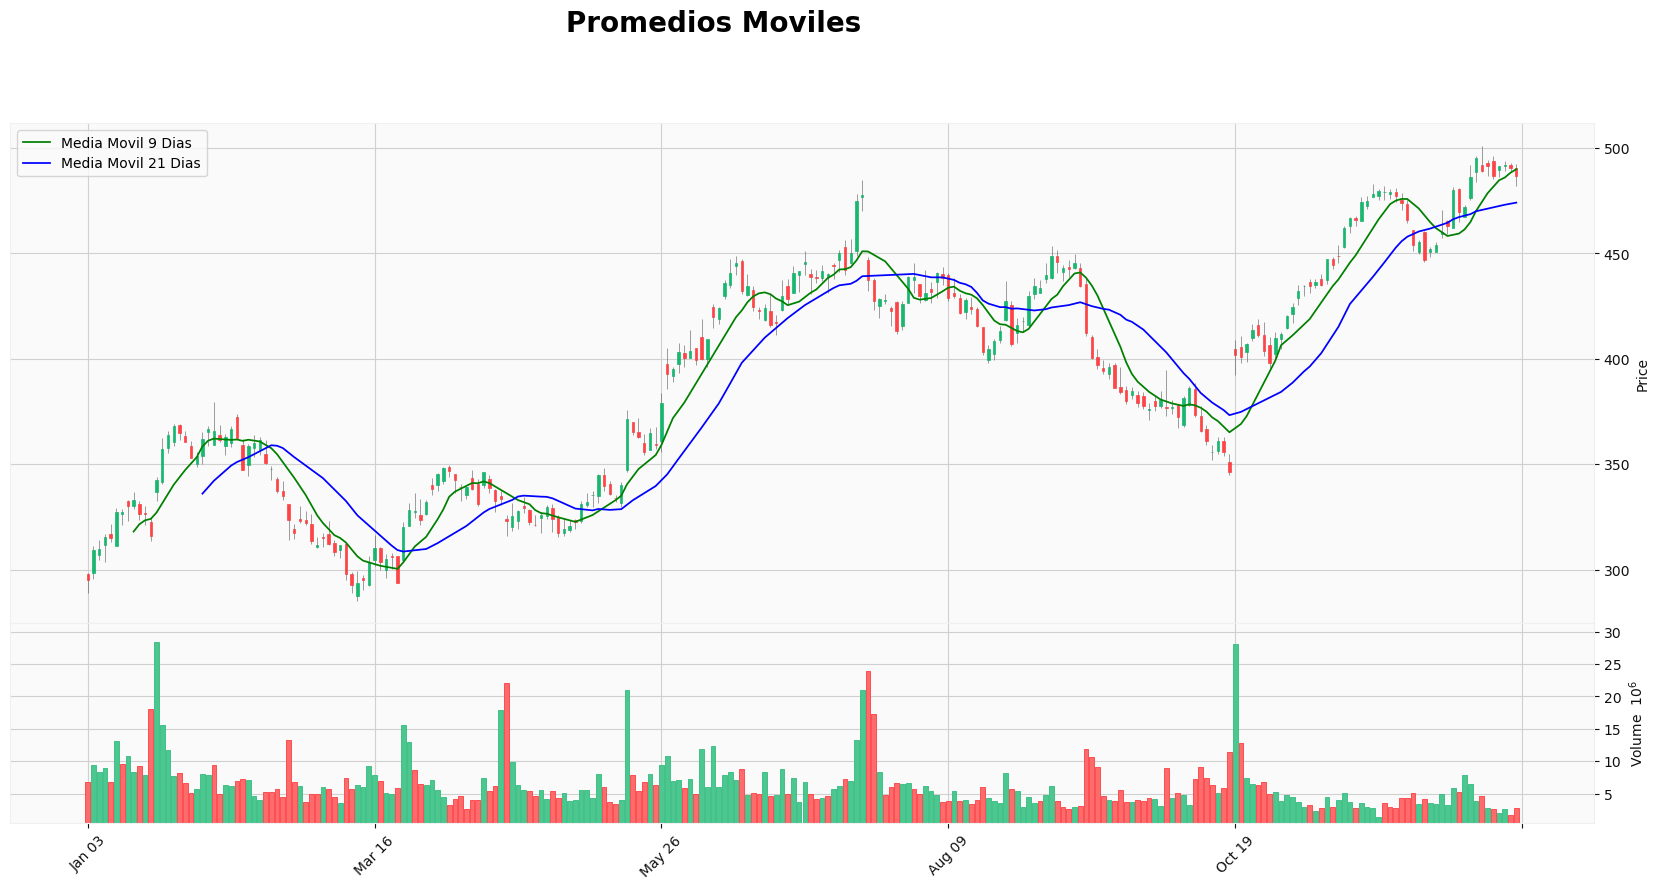

In [12]:
# Graficar
media_mov_plots = [
    mpf.make_addplot(media_movil_9, label="Media Movil 9 Dias", color="green", type="line" ),
    mpf.make_addplot(media_movil_21, label="Media Movil 21 Dias", color="blue", type="line" )
]

mpf.plot(df, type="candle", style="yahoo", volume=True, figsize=(22,10), addplot=media_mov_plots, figscale=3.0,
         title=dict(title="Promedios Moviles", size=20))

plt.show()

In [ ]:
# Recordatorio:
#   - La Media Móvil Simple (SMA) es útil para identificar tendenciasa y niveles de Soporte y Resistencia.
#   - Un periodo más largo en la SMA indica un mayor rezago en nuestro indicador.
#   - Operar con una SMA sola puede llevar a malas interpretaciones; por lo tanto, se recomienda utilizarla en conjunto
#     con otra SMA para obtener señales de compra o venta más precisas.